# Import package

In [1]:
#supposedly these were already done from command line
#git clone https://github.com/hshadman/pyheteromap.git
#cd pyheteromap
#python -m pip install -e .

In [2]:
import pyheteromap
from pyheteromap import PyHeteroMap
import os

# Initialize

## Examples are from the human IDR-ome dataset (https://www.nature.com/articles/s41586-023-07004-5)

In [6]:
h3 = PyHeteroMap('PEI_0p',traj_file_dir='../../md_all.mdcrd',
                 prmtop_file_dir='../../pei_only.prmtop',skip_frames=0)

Note: The first 0 frames in the trajectory were skipped.

Note: The code as written is for CG simulations (one "bead" per amino acid residue).

If all-atom, users may want CA atoms instead,
by making the below modification in set_trajectory and inside the loop in initialize_30mer_subchain, if also examining subchains:

self._first_atom_index = t.topology.select("name CA and residue 0")[0]
self._last_atom_index  = t.topology.select(f"name CA and residue {self._n_residues - 1}")[0]



Data loading...

Data loaded. Visualizing now, this could take some time.
Loaded reference GW chain from: /project/hshadman/hshadman/polym_sep/github_subchain_code/src/pyheteromap/reference_GW_chainlength_100.csv

500000 GW snapshots processed
1000000 GW snapshots processed


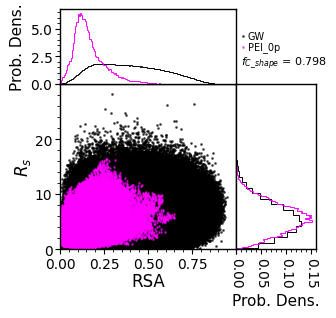

In [7]:
h3.mod_RSA_Rs_compute_3dplot_from_seq_name()

In [9]:
h3.protein_df['Rg']=h3.protein_df['Rg2'].values**0.5
h3.protein_df

,RSA,Rg2,Ree2,ratio,Rg
0,0.186919,0.727086,3.372199,4.637961,0.852694
1,0.219473,0.743874,3.528136,4.742923,0.862481
2,0.217538,0.753151,3.539945,4.700182,0.867842
3,0.251513,0.788699,4.314828,5.470817,0.888087
4,0.245172,0.773854,3.784270,4.890159,0.879690
...,...,...,...,...,...
44996,0.148197,0.931299,2.241298,2.406635,0.965039
44997,0.130029,0.896317,1.611562,1.797982,0.946740
44998,0.117313,0.851648,1.557848,1.829217,0.922848
44999,0.125517,0.838542,1.162748,1.386630,0.915720


In [3]:
# example 1
h1 = PyHeteroMap('Q8WV44_43_186',traj_file_dir='test_data/traj1.xtc',
                 prmtop_file_dir='test_data/top1.pdb') # 'Q8WV44_43_186' is the seq_name for the IDR in traj1, top1. 
# example 2
h2 = PyHeteroMap('Q9UIF8_1259_1347',traj_file_dir='test_data/traj2.xtc',
                 prmtop_file_dir='test_data/top2.pdb') # 'Q9UIF8_1259_1347' is the seq_name for the IDR in traj2, top2. 

Note: The first 10 frames in the trajectory were skipped.

The code as written is for CG simulations (one "bead" per amino acid residue).

If all-atom, users may want CA atoms instead:

self._first_atom_index = t.topology.select("name CA and residue 0")[0]
self._last_atom_index  = t.topology.select(f"name CA and residue {self._n_residues - 1}")[0]

Modify accordingly in set_trajectory and inside the subchain loop in initialize_30mer_subchain.
Note: The first 10 frames in the trajectory were skipped.

The code as written is for CG simulations (one "bead" per amino acid residue).

If all-atom, users may want CA atoms instead:

self._first_atom_index = t.topology.select("name CA and residue 0")[0]
self._last_atom_index  = t.topology.select(f"name CA and residue {self._n_residues - 1}")[0]

Modify accordingly in set_trajectory and inside the subchain loop in initialize_30mer_subchain.


# Generate Global (whole chain) Conformational Ensemble

Data loading...

Data loaded. Visualizing now, this could take some time.
Loaded reference GW chain from: /project/hshadman/hshadman/polym_sep/github_subchain_code/src/pyheteromap/reference_GW_chainlength_100.csv

500000 GW snapshots processed
1000000 GW snapshots processed


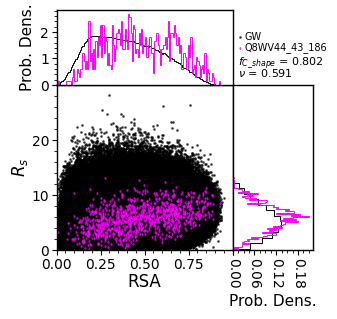

In [4]:
# example 1
h1.mod_RSA_Rs_compute_3dplot_from_seq_name()

Data loading...

Data loaded. Visualizing now, this could take some time.
Loaded reference GW chain from: /project/hshadman/hshadman/polym_sep/github_subchain_code/src/pyheteromap/reference_GW_chainlength_100.csv

500000 GW snapshots processed
1000000 GW snapshots processed


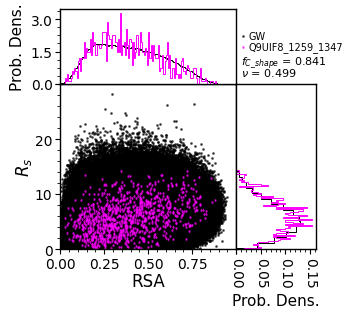

In [5]:
# example 2
h2.mod_RSA_Rs_compute_3dplot_from_seq_name()

# Generate Subchain Plots

## Important: Subchain data needs to be initialized before generating subchain plots.

In [6]:
# example 1

# FASTA_CSV = path to a csv file connecting seq_name to fasta sequence (provided)
FASTA_CSV = os.path.join(os.path.dirname(pyheteromap.__file__), "Tesei_2024_IDR-ome_fasta_sequences.csv") 

h1.initialize_30mer_subchain(fasta_source = FASTA_CSV) # the subchain data is stored in h1._subchain_df


NOTE: Subchain calculation might take longer for longer peptides/IDRs.

NOTE: If peptide length is smaller than 5 residues, nu cannot be computed.

If the fasta sequences in the csv file are arranged differently,modify this section of the code to properly read in fasta_sequence.

If <= 60 residues, the moving window is ~1/3rd (by default) of the number of residues.
If > 60 residues, the moving window is 30 residues.

AFRC calculates in Angstrom units.
Since MDTraj calculations are in nm units, a conversion variable "scale" is applied.
If needed, modify the "scale" variable in initialize_30mer_subchain.

Subchain data generated and stored in _subchain_df.



## visualize how polymer properties vary at the subchain level

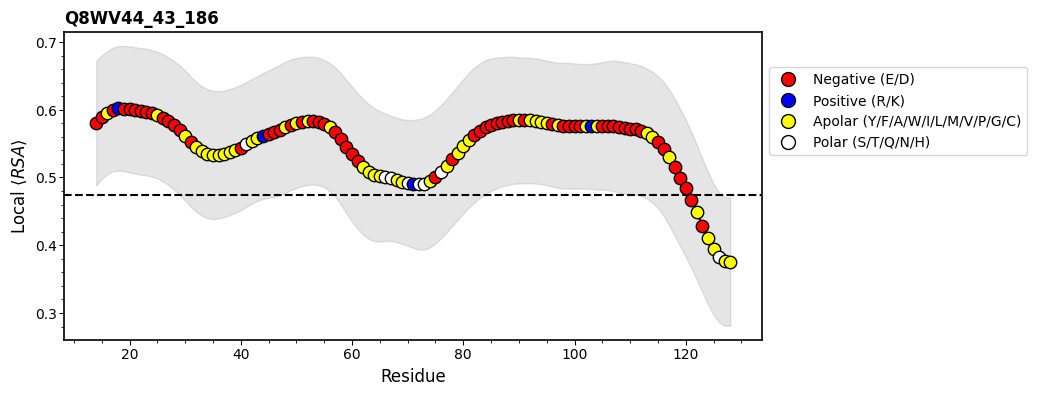

In [7]:
# example 1
# dotted line shows global
h1.plot_subchain_RSA(9,4) # provide figure width, figure height

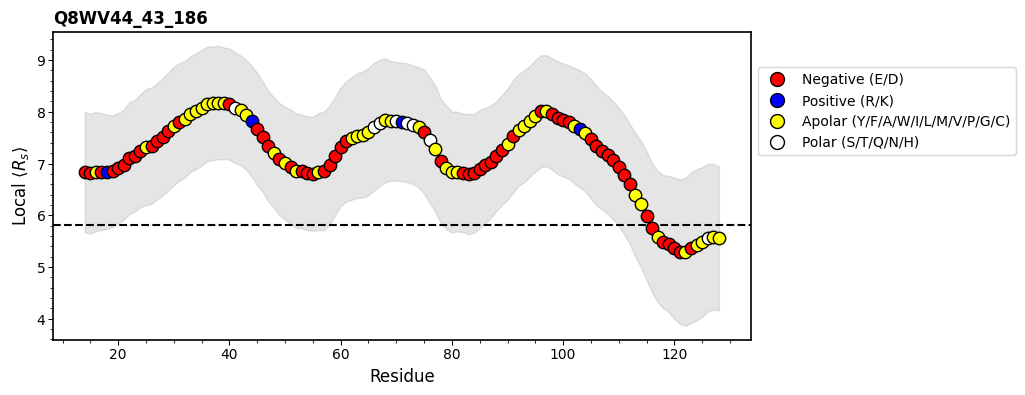

In [8]:
# example 1
# dotted line shows global
h1.plot_subchain_Rs(9,4) # provide figure width, figure height

This is computing a ⟨R₍g₎ / ⟨R₍g₎ᶿ⟩⟩ plot.
⟨R₍g₎ / ⟨R₍g₎ᶿ⟩⟩ is also referred to as ⟨α⟩ in the associated paper.
⟨R₍g₎ᶿ⟩ was computed directly from sequence using an Analytical Flory Random Coil (AFRC) reference, Alston et al. 2023


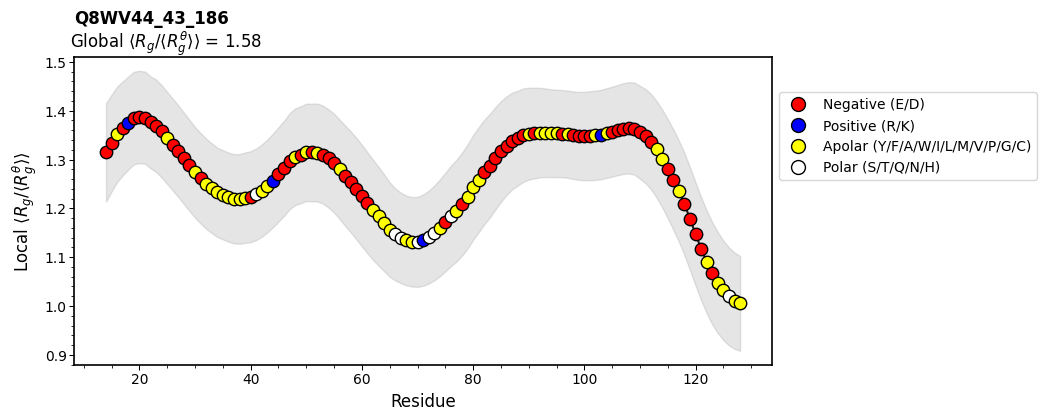

In [9]:
# example 1

h1.plot_subchain_Rg_over_Rgtheta(9,4) # provide figure width, figure height

nu formula is from Tesei et al. 2024


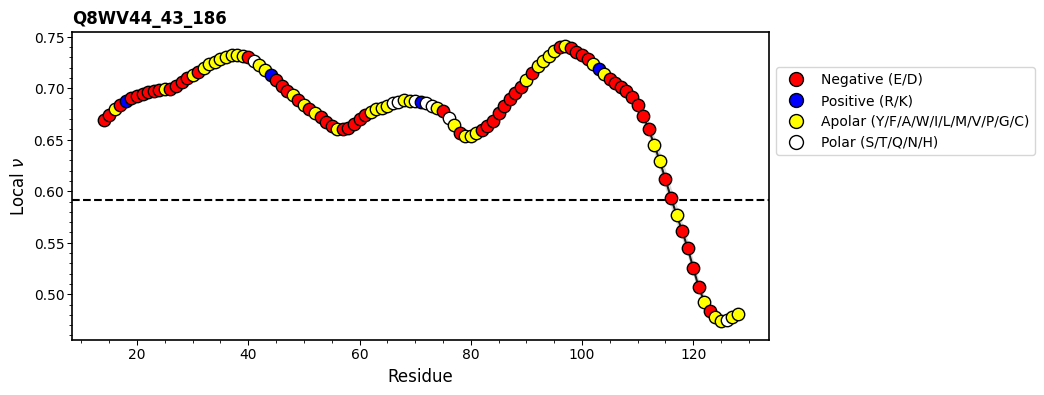

In [10]:
# example 1
# dotted line shows global
# uses nu formula from Tesei et al. 2024
h1.plot_subchain_nu(9,4) # provide figure width, figure height

## select one or more subchains and generate (RSA, _R<sub>s</sub>_) plots of selected subchains 

GW data already present (source: reference). Skipping reload.

500000 GW snapshots processed
1000000 GW snapshots processed


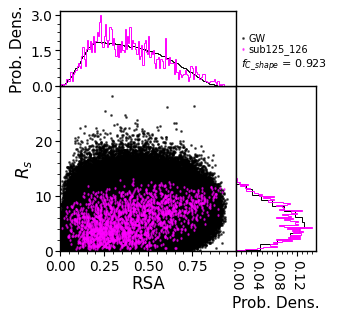

In [11]:
# example 1

# h1._subchain_df has mid_residue column. Subchain trajectories can be identified using the mid-residue (i.e. middle residue) value

# below, conformational ensembles are plotted for subchains with mid_residues 125 and 126

# a label must be provided

h1.mod_RSA_Rs_compute_3dplot_for_subchain(mid_residues=[125,126],label ='sub125_126')

# Simulate a GW chain

In [12]:
h1.regenerate_GW_chain(100,1000) # a GW chain of 100 monomers, 1000 snapshots in simulation

# To save this new GW chain, do h1.export_gw_csv('./GW_regenerated.csv')

# now this new chain replaces the default chain data in h1. To recover that default GW data, h1.reinitialize_gw_reference()

# GW chain data stored in h1.gw_df

# each row in h1.gw_df is a snapshot of the GW simulation

chain_length=100, Nosnaps=1000, interval= 1
New GW chain generated and stored in self.gw_df.
To save, call export_gw_csv('GW_regenerated.csv').


# Generate (RSA, _R<sub>s</sub>_) Scatter Plots from a csv file containing RSA and _R<sub>s</sub>_ data
# NO trajectory needed

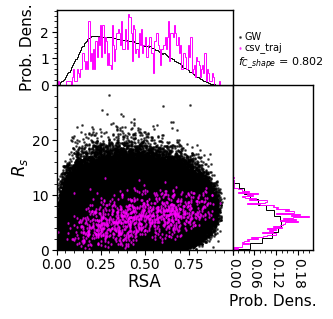

In [13]:
%%capture --no-display output

# random example - no trajectory but a csv file containing Rs and RSA are available.
h3 = PyHeteroMap('csv_traj',traj_file_dir=None,
                 prmtop_file_dir=None) 

# must provide a label for the protein data
h3.mod_RSA_Rs_compute_3dplot_from_csv('./test_data/test_idr.csv', label = 'csv_traj')